In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib

import numpy as np
import os

import umap.umap_ as umap

from src.connection import local_client as client

/Users/huqiaowen/Library/Python/3.8/lib/python/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/huqiaowen/Library/Python/3.8/lib/python/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/huqiaowen/Library/Python/3.8/lib/python/site-packages/umap/distances.

In [2]:
variables_path = "data/variables"
figures_path = "data/fi## Import datagures"
berenslab_data_path = "data/embeddings"

## Fetch training data from local open research

In [3]:
# fetch data
start_date = "2019-01-01"
end_date = "2021-12-31"

index_name = "frameintell_aux_minilmv6"

query = {
    "query": {"range": {"articleDate": {"gte": start_date, "lte": end_date}}}
}

data = client.search(
    body=query, index=index_name, size=10000, scroll="10m", pretty=True
)

articals = data["hits"]["hits"]

scroll_id = data["_scroll_id"]
scroll_size = len(data["hits"]["hits"])

while scroll_size > 0:
    print(scroll_id,scroll_size)
    data = client.scroll(scroll_id=scroll_id, scroll="10m")

    articals += data["hits"]["hits"]

    scroll_id = data["_scroll_id"]
    scroll_size = len(data["hits"]["hits"])

print(len(articals))
pubmed_ids = []
article_dates = []
embeddings = np.empty([len(articals), 384])
for i in range(len(articals)):
    pubmed_ids.append(articals[i]["_id"])
    article_dates.append(articals[i]["_source"]["articleDate"])
    embeddings[i] = articals[i]["_source"]["vector"]

# save embedding
np.save(os.path.join(berenslab_data_path, "pubmed_ids_umap"), pubmed_ids)
np.save(os.path.join(berenslab_data_path, "article_dates_umap"), article_dates)

FGluY2x1ZGVfY29udGV4dF91dWlkDXF1ZXJ5QW5kRmV0Y2gBFjNWZVFGd1hCVHVpRzFBRXI2U3BPU3cAAAAAAAAFpBZMMWVLRTJfblF4eXl4TzVoUnJvRUhn 10000
FGluY2x1ZGVfY29udGV4dF91dWlkDXF1ZXJ5QW5kRmV0Y2gBFjNWZVFGd1hCVHVpRzFBRXI2U3BPU3cAAAAAAAAFpBZMMWVLRTJfblF4eXl4TzVoUnJvRUhn 10000
FGluY2x1ZGVfY29udGV4dF91dWlkDXF1ZXJ5QW5kRmV0Y2gBFjNWZVFGd1hCVHVpRzFBRXI2U3BPU3cAAAAAAAAFpBZMMWVLRTJfblF4eXl4TzVoUnJvRUhn 1769
21769


# UMAP

In [4]:
umapModel = umap.UMAP(metric="manhattan", n_components=2)

umap_embeddings = umapModel.fit_transform(embeddings)

In [5]:
# save the result
np.save(os.path.join(variables_path, "umap_reparsed"), umap_embeddings)

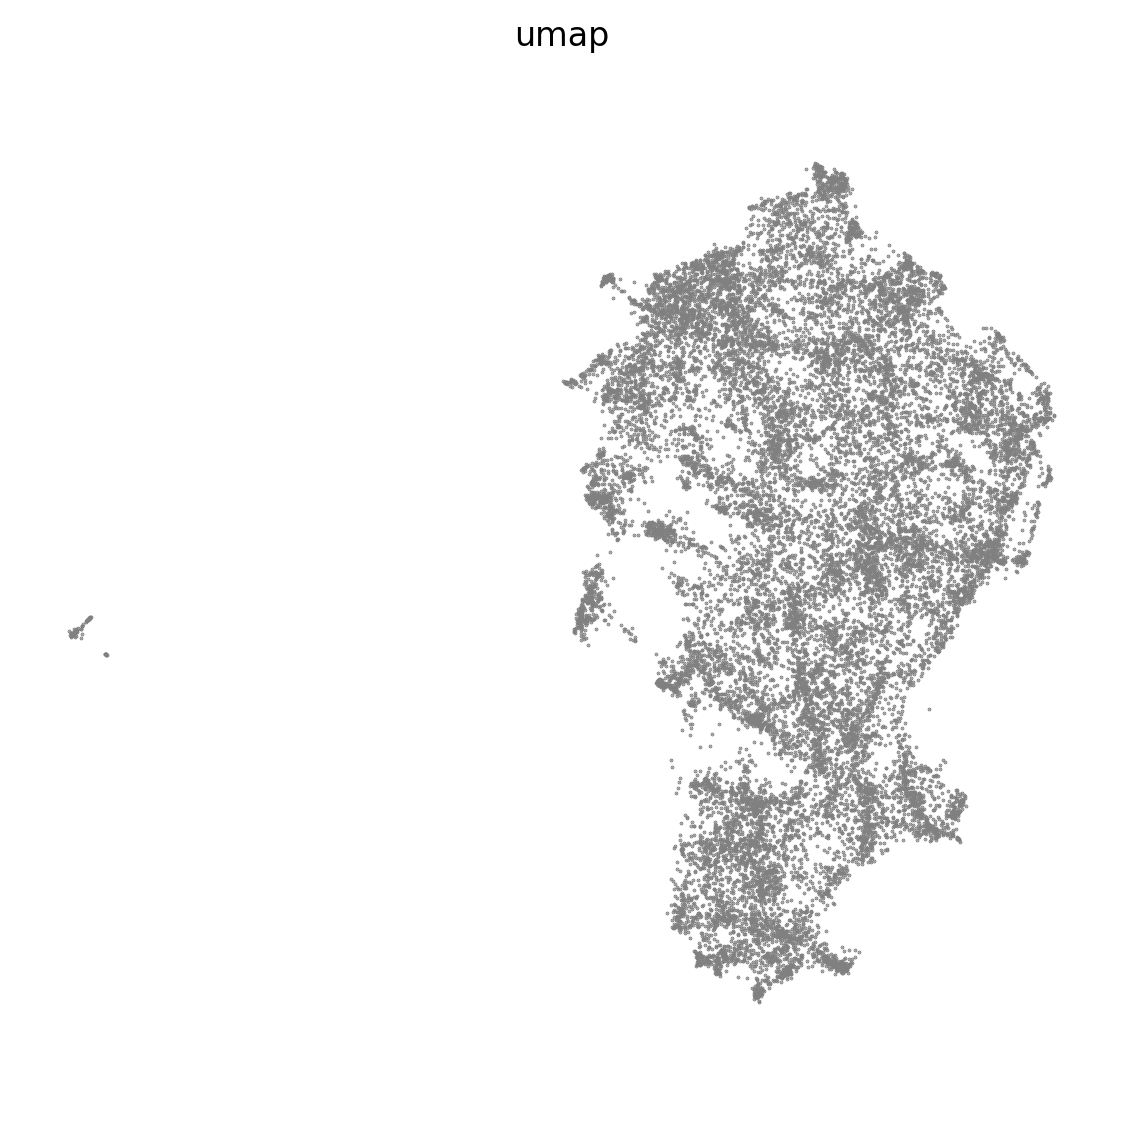

In [6]:
%matplotlib inline
# umap_embeddings = np.load(os.path.join(variables_path, "umap_reparsed.npy"))
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=200, layout="constrained")

ax.scatter(
    umap_embeddings[:, 0],
    umap_embeddings[:, 1],
    s=0.5,
    c="grey",
    marker=".",
)
ax.set_title("umap")
ax.axis("equal")
ax.grid()
ax.axis("off")
plt.show()

fig.savefig('data/results/umap.png')